## Defining the equations of motion of the rocket during various phases of flight
- Integrating the equations of motion
- Comparing it to OpenRocket results

In [ ]:
import numpy as np
import scipy.integrate as integrate
import scipy.interpolate as interpolate
import matplotlib.pyplot as plt
import pandas as pd

# Setting up plotting style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 22 # pt
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8) # inches
plt.rcParams['axes.titlesize'] = 20 # pt
plt.rcParams['axes.labelsize'] = 20 # pt
plt.rcParams['figure.labelsize'] = 20 # pt
plt.rcParams['xtick.labelsize'] = 20 # pt
plt.rcParams['ytick.labelsize'] = 20 # pt
plt.rcParams['legend.fontsize'] = 18 # pt
plt.rcParams['mathtext.fontset'] = 'cm'

### Let's split up the ascent phase of the flight into two parts: the launch rod phase and the free flight phase.

During the launch rod phase, the rocket is constrained to follow the direction of the launch rod, which is at an angle $\theta$ from the vertical. During the free flight phase, the rocket is free to move in any direction.

### Phase 1: Launch Rod Phase
Assume that the launch rod is canted by an angle $\theta_0$ from the vertical. Starting with the acceleration of the rocket along the launch rod, we can write:
$$
\begin{align*}
    \sum F_{rod} &= m \ddot{s} \\
    \tau - D - mg \cos(\theta_0) &= m \ddot{s} \\
    m \ddot{s} + D_{rod} &= \tau - mg \cos(\theta_0) \\
    m \ddot{s} + \dfrac{1}{2} \rho \dot{s}^2 S C_D &= \tau - mg \cos(\theta_0) \\
    \ddot{s} &= \dfrac{1}{m} \left(\tau - mg \cos(\theta_0) - \dfrac{1}{2} \rho \dot{s}^2 S C_D\right)
\end{align*}
$$

The x and y components of the position and velocity can be found using the angle of the launch rod:
$$
\begin{align*}
    x &= s \sin(\theta_0) \\
    y &= s \cos(\theta_0) \\
    v_x &= \dot{s} \sin(\theta_0) \\
    v_y &= \dot{s} \cos(\theta_0)
\end{align*}
$$

How does mass change with time? We can write:
$$
\begin{align*}
    m(t) &= m_0 + \int_0^t \dot{m}(t') dt' \\
    \dot{m}(t) &= - \tau(t) \dfrac{m_p}{I_{total}}
\end{align*}
$$

The initial conditions are:
$$
\begin{align*}
    x(0) &= 0 \\
    y(0) &= 0 \\
    v_x(0) &= 0 \\
    v_y(0) &= 0 \\
    m(0) &= m_0 \\
    \dot{m}(0) &= 0
\end{align*}
$$

Writing this phase in state-space form, we have:
$$
\begin{align*}
    \dot{x} &= v_x \\
    \dot{y} &= v_y \\
    \dot{v}_x &= \dfrac{1}{m} \left(\tau - mg \cos(\theta_0) - \dfrac{1}{2} \rho v^2 S C_D\right) \sin(\theta_0) \\
    \dot{v}_y &= \dfrac{1}{m} \left(\tau - mg \cos(\theta_0) - \dfrac{1}{2} \rho v^2 S C_D\right) \cos(\theta_0) \\
    \dot{m} &= -\tau \dfrac{m_p}{I_{total}}
\end{align*}
$$

Defining state vector as $\mathbf{X} = [x, y, v_x, v_y, m]^T$, we can write the system as:
$$\dot{\mathbf{X}} = \mathbf{f}(\mathbf{X}, t)$$

Once $s \geq L$ (length of the launch rod), we transition to the free flight phase.

### Phase 2: Free Flight Phase
The initial conditions for the free flight phase are the final conditions from the launch rod phase:
$$\begin{align*}
    x(0) &= L \sin(\theta_0) \\
    y(0) &= L \cos(\theta_0) \\
    v_x(0) &= \dot{s}_{\text{final}} \sin(\theta_0) \\
    v_y(0) &= \dot{s}_{\text{final}} \cos(\theta_0) \\
    m(0) &= m_{\text{final}} \\
    \dot{m}(0) &= \dot{m}_{\text{final}}
\end{align*}
$$

Starting with sum of forces in y direction, where positive y is upwards. Assuming a launch rod cant of $\theta$, we have:
$$
\begin{align*}
    \sum F_y &= m \ddot{y} \\
    \tau \cos(\theta) - D \cos(\theta) - mg &= m \ddot{y} \\
    m \ddot{y} + D \cos(\theta) &= \tau \cos(\theta) - mg \\
    m \ddot{y} + \dfrac{1}{2} \rho v^2 S C_D \cos(\theta) &= \tau \cos(\theta) - mg
\end{align*}
$$

Similarly, for the x direction, we have:
$$
\begin{align*}
    \sum F_x &= m \ddot{x} \\
    \tau \sin(\theta) - D \sin(\theta) &= m \ddot{x} \\
    m \ddot{x} + D \sin(\theta) &= \tau \sin(\theta) \\
    m \ddot{x} + \dfrac{1}{2} \rho v^2 S C_D \sin(\theta) &= \tau \sin(\theta)
\end{align*}
$$

For simplicity, we must have the rocket following the direction of motion. $\theta$ is the angle of the rocket's orientation relative to the vertical, so we can write:
$$
\begin{align*}
    \theta &= \arctan\left(\dfrac{\dot{x}}{\dot{y}}\right) \\
\end{align*}
$$

Solving for the components of $\theta$ gives us:
$$
\begin{align*}
    \cos(\theta) &= \dfrac{\dot{y}}{v} \\
    \sin(\theta) &= \dfrac{\dot{x}}{v}
\end{align*}
$$

Plugging this relationship into the equations of motion, we have:
$$
\begin{align*}
    m \ddot{y} + \left(\dfrac{1}{2} \rho S C_D\right) \dot{y} v &= \tau \dfrac{\dot{y}}{v} - mg \\
    m \ddot{x} + \left(\dfrac{1}{2} \rho S C_D\right) \dot{x} v &= \tau \dfrac{\dot{x}}{v}
\end{align*}
$$

How does mass change with time? We can write:
$$
\begin{align*}
    m(t) &= m_0 + \int_0^t \dot{m}(t') dt' \\
    \dot{m}(t) &= - \tau(t) \dfrac{m_p}{I_{total}}
\end{align*}
$$

Writing the system of equations in state-space form, we have:
$$
\begin{align*}
    \dot{x} &= v_x \\
    \dot{y} &= v_y \\
    \dot{v}_x &= \dfrac{1}{m} \left(\tau \dfrac{\dot{x}}{v} - \dfrac{1}{2} \rho S C_D \dot{x} v \right) \\
    \dot{v}_y &= \dfrac{1}{m} \left(\tau \dfrac{\dot{y}}{v} - \dfrac{1}{2} \rho S C_D \dot{y} v - mg \right) \\
    \dot{m} &= -\tau \dfrac{m_p}{I_{total}}
\end{align*}
$$

Defining state vector as $\mathbf{X} = [x, y, v_x, v_y, m]^T$, we can write the system as:
$$
\dot{\mathbf{X}} = \mathbf{f}(\mathbf{X}, t)
$$

Defining some useful constants:

In [2]:
g = 9.81  # Gravitational acceleration (m/s^2)
S = 0.01897 # Reference area (m^2)
Cd = 0.5 # Drag coefficient
P0 = 101325 # Ground atmospheric pressure (Pa)
T0 = 19 # Ground standard temperature (C)
L = 3.66 # Length of the launch rod (m) (12 ft)

# Motor parameters
Isp = 242 # Specific impulse (s)
v_ex = Isp * g # Effective exhaust velocity (m/s)
t_burn = 2.309 # Burn time (s)
m_prop = 1.825 # Propellant mass (kg)
Itotal = 4329.2 # Total impulse (N-s)

Defining initial conditions:

In [3]:
x0 = 0.0 # Initial horizontal position (m)
y0 = 0.0 # Initial vertical position (m)
v_x0 = 0.0 # Initial horizontal velocity (m/s)
v_y0 = 0.0 # Initial vertical velocity (m/s)
theta0 = 7.5 # Initial launch rod cant (degrees)
m0 = 20.68 # Initial mass of the rocket (kg)
m_dot0 = 0 # Initial mass flow rate (kg/s)

We must define the following varying parameters:
$$
\tau(t) \\
\rho(y) \\
$$

Parsing thrust curve data from the AeroTech L1940X motor:

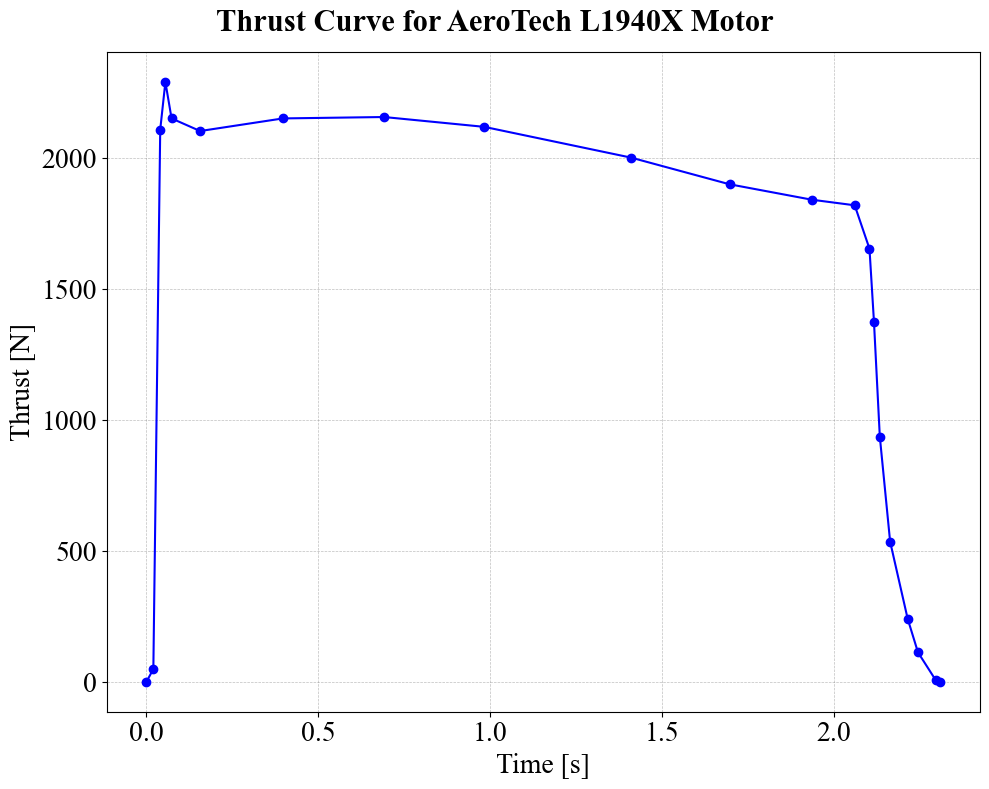

In [4]:
thrust_data = pd.read_csv('AeroTech_L1940X.csv')
thrust_time = thrust_data['Time (s)'].values
thrust_values = thrust_data['Thrust (N)'].values
thrust_interp = interpolate.interp1d(thrust_time, thrust_values, bounds_error=False, fill_value=0.0)

fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Thrust Curve for AeroTech L1940X Motor')

ax.plot(thrust_time, thrust_values, color='blue', linestyle='-', marker='o')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Thrust [N]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.show()

Defining atmosphere class to compute ground density:

Initialized Launch Conditions:
Ground Temp: 292.15 K | Ground Pressure: 101325.00 Pa
Calculated Ground Density: 1.2082 kg/m^3



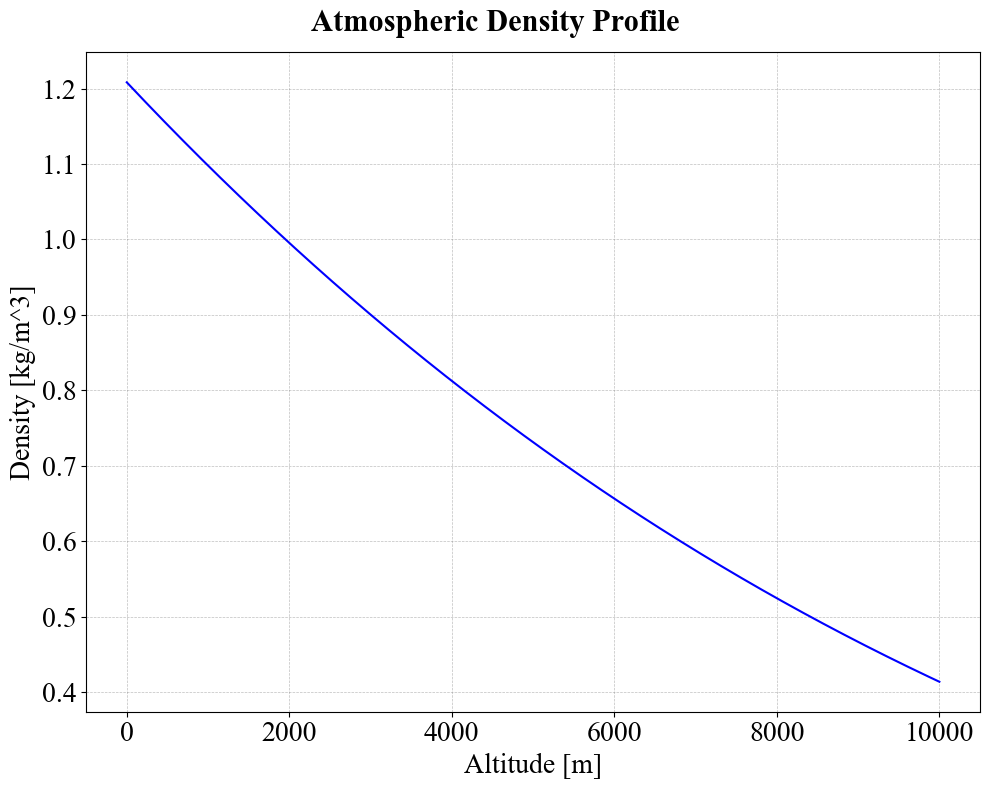

In [5]:
class CustomAtmosphere:
    def __init__(self, ground_temp_C, ground_pressure_Pa):
        '''
        Initializes the atmosphere with day-of-launch ground conditions.
        '''
        # Constants
        self.L = 0.0065         # Lapse rate (K/m)
        self.R = 287.05         # Specific gas constant for dry air (J/(kg*K))
        self.g = 9.80665        # Gravity (m/s^2)
        
        # Ground Conditions
        self.T0 = ground_temp_C + 273.15  # Convert Celsius to Kelvin
        self.P0 = ground_pressure_Pa
        
        # Calculate Ground Density
        self.rho0 = self.P0 / (self.R * self.T0)
        print(f'Initialized Launch Conditions:')
        print(f'Ground Temp: {self.T0:.2f} K | Ground Pressure: {self.P0:.2f} Pa')
        print(f'Calculated Ground Density: {self.rho0:.4f} kg/m^3\n')

    def density(self, h):
        '''
        Returns air density (kg/m^3) at a given altitude h (meters).
        Works with both scalar floats (for the solver) and numpy arrays (for plotting).
        '''
        # Ensure we don't calculate below ground level
        h = np.maximum(h, 0.0) 
        
        # Troposphere equations
        T = self.T0 - self.L * h
        P = self.P0 * (T / self.T0)**(self.g / (self.L * self.R))
        rho = P / (self.R * T)
        
        return rho
    
atmosphere = CustomAtmosphere(ground_temp_C=T0, ground_pressure_Pa=P0)

fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Atmospheric Density Profile')

h_values = np.linspace(0, 10000, 1000) # Altitude range from 0 to 10 km
rho_values = atmosphere.density(h_values)
ax.plot(h_values, rho_values, label='Density vs Altitude', color='blue')
ax.set_xlabel('Altitude [m]')
ax.set_ylabel('Density [kg/m^3]')
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()

Defining differential equation for the system:

In [6]:
# Defining equations of motion of rocket during boost and coast
def AscentEOM(t, X):
    # Unpack the state vector
    x, y, vx, vy, m = X

    # Calculating varying parameters
    thrust = thrust_interp(t) # Instantaneous thrust (N)
    rho = atmosphere.density(y) # Air density at current altitude (kg/m^3)
    v = np.sqrt(vx**2 + vy**2) # Speed (m/s)

    # Checking for phase of flight
    s = np.sqrt(x**2 + y**2) # Distance from launch point (m)
    if s < L:
        # Calculating derivatives
        x_dot = vx
        y_dot = vy
        vx_dot = 1/m * (thrust - m*g*np.cos(np.radians(theta0)) - 0.5*rho*v**2*S*Cd) * np.sin(np.radians(theta0))
        vy_dot = 1/m * (thrust - m*g*np.cos(np.radians(theta0)) - 0.5*rho*v**2*S*Cd) * np.cos(np.radians(theta0))
        m_dot = -thrust * m_prop/Itotal

    # After leaving the launch rod, the rocket is free
    else:
        # Calculating derivatives
        x_dot = vx
        y_dot = vy
        vx_dot = 1/m * (thrust*x_dot/v - 0.5*rho*S*Cd*x_dot*v)
        vy_dot = 1/m * (thrust*y_dot/v - 0.5*rho*S*Cd*y_dot*v - m*g)
        m_dot = -thrust * m_prop/Itotal # Mass flow rate is negative (mass decreases over time)

    return np.array([x_dot, y_dot, vx_dot, vy_dot, m_dot])

Defining time span for integration:

In [7]:
# 1. Setup Time Span and Initial State
t_end = 30  # Total simulation time (s)
t_span = (0, t_end)  # (Start time, End time) for the solver limit
t_eval = np.linspace(0, t_end, 1000)  # The specific time stamps to record the output
X0 = np.array([x0, y0, v_x0, v_y0, m0])  # Your initial conditions

# 2. Define an Event Function (Optional but highly recommended)
# This will automatically halt the solver the exact millisecond the rocket reaches apogee
def apogee_event(t, X):
    y = X[1]   # Altitude is index 1
    vy = X[3]  # Vertical velocity is index 3
    
    # Safety Lock: Do not track apogee until the rocket is at least 10 meters in the air.
    # We return 1.0 (a positive number) to prevent the root-finder from crossing zero.
    if y < 10.0:
        return 1.0 
    
    # Once above 10 meters, track the actual vertical velocity
    return vy

apogee_event.terminal = True  # Tell the solver to stop when this event occurs
apogee_event.direction = -1   # Only trigger when vy goes from positive to negative

In [8]:
# 3. Execute the Solver
solution = integrate.solve_ivp(
    fun=AscentEOM,
    t_span=t_span,
    y0=X0,
    method='DOP853',       # Explicitly call the 8th order Runge-Kutta method
    t_eval=t_eval,         # Force the solver to output data at your 1000 points
    events=apogee_event,   # Attach the apogee tracker
    max_step=0.01          # Optional: Cap max step size to prevent jumping over the rail phase
)

In [12]:
# 4. Extract the Results
if solution.success:
    # The output array is shaped (num_state_variables, num_time_steps)
    # We unpack it back into individual arrays for easy handling
    x_out  = solution.y[0]
    y_out  = solution.y[1]
    vx_out = solution.y[2]
    vy_out = solution.y[3]
    m_out  = solution.y[4]
    t_out  = solution.t

    print(f"Integration successful! Reached apogee at t = {t_out[-1]:.2f}s")
    print(f"Apogee Altitude: {y_out[-1]:.2f} m | {y_out[-1] * 3.28084:.2f} ft")
    print(f"Apogee Time: {t_out[-1]:.2f} s")
    print(f"Final Mass: {m_out[-1]:.2f} kg | {m_out[-1] * 2.20462:.2f} lbs")
else:
    print("Integration failed:", solution.message)

Integration successful! Reached apogee at t = 17.00s
Apogee Altitude: 1429.27 m | 4689.21 ft
Apogee Time: 17.00 s
Final Mass: 18.86 kg | 41.58 lbs


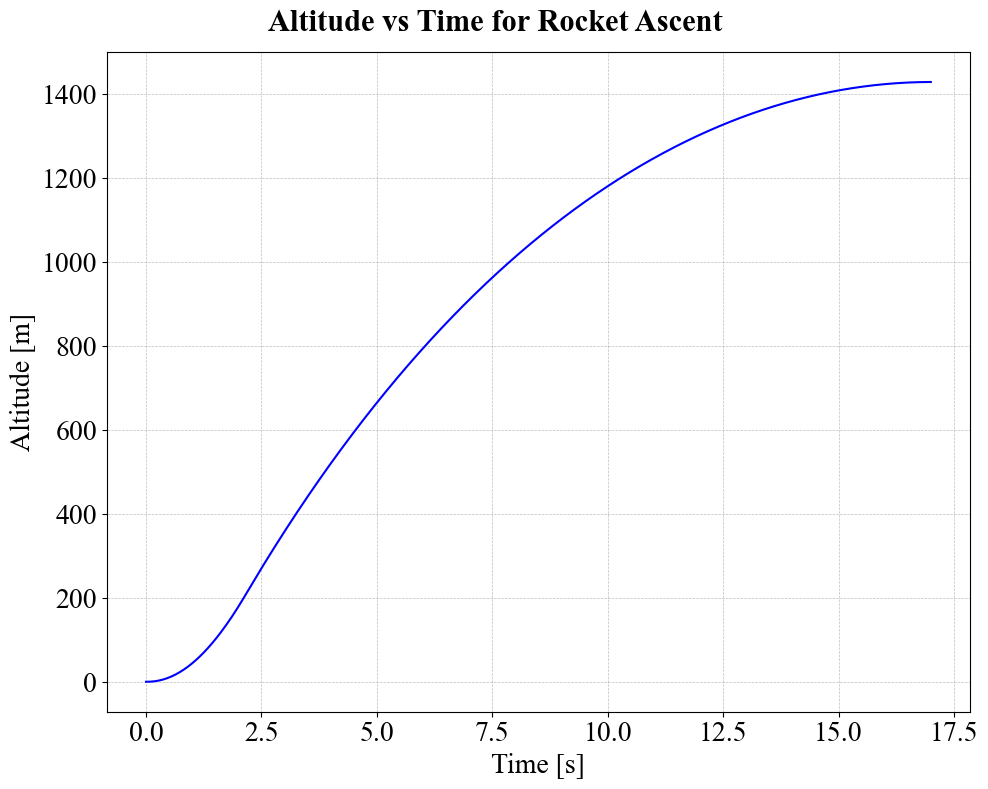

In [10]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Altitude vs Time for Rocket Ascent')

ax.plot(t_out, y_out, label='Altitude vs Time', color='blue')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [m]')

ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.show()

Importing OpenRocket results for comparison:

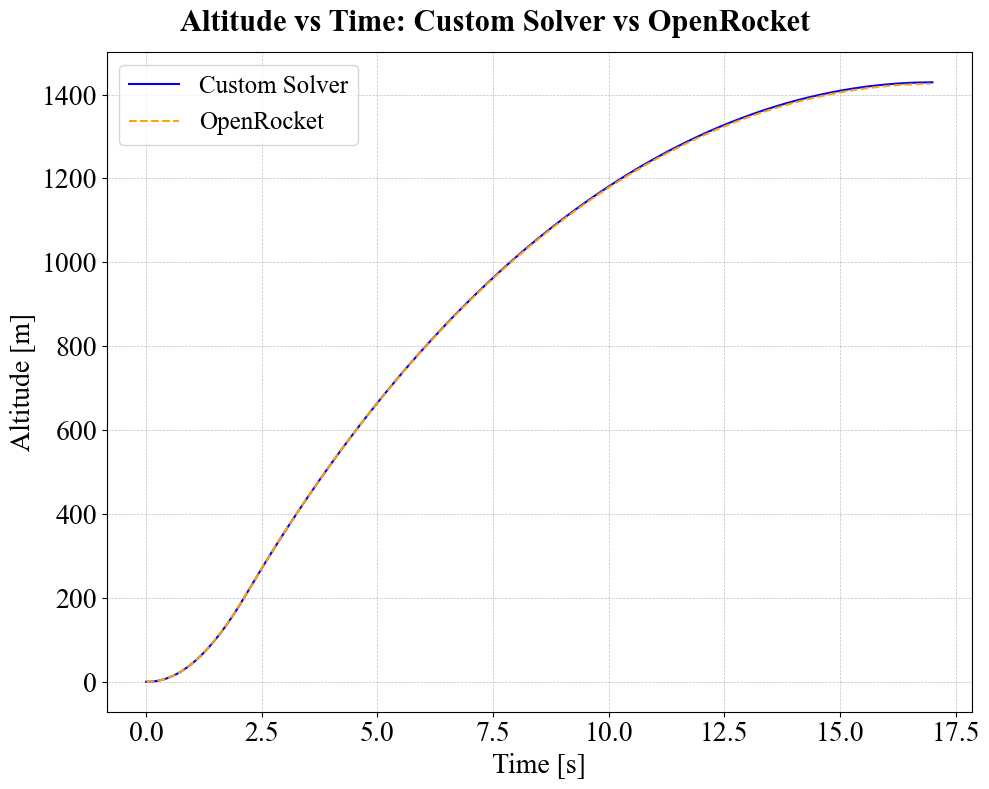

In [14]:
openrocket_data = pd.read_csv('OpenRocketFRRFlight.csv', comment='#') # Skip the comment lines at the top
openrocket_time = openrocket_data['Time (s)'].values[np.where(openrocket_data['Time (s)'].values <= t_out[-1])]
openrocket_altitude = openrocket_data['Altitude (ft)'].values[np.where(openrocket_data['Time (s)'].values <= t_out[-1])] * 0.3048 # Convert feet to meters

fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Altitude vs Time: Custom Solver vs OpenRocket')

ax.plot(t_out, y_out, label='Custom Solver', color='blue')
ax.plot(openrocket_time, openrocket_altitude, label='OpenRocket', color='orange', linestyle='--')

ax.set_xlabel('Time [s]')
ax.set_ylabel('Altitude [m]')

# ax.set_xlim(0, t_out[-1]+5)

ax.legend()
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig('Altitude_vs_Time_Comparison.png', dpi=300)

plt.show()